In [2]:
import os

# Install the Kaggle library
!pip install kaggle

In [6]:
import os
import json

# Create the .kaggle directory if it doesn't exist
kaggle_dir = os.path.join(os.path.expanduser('~'), '.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Define Kaggle API credentials
kaggle_creds = {
    "username": "sanaullahtareen1",
    "key": "KGAT_b69264e9b4cf48ed9acadbeb4dfaa678"
}

# Write credentials to kaggle.json
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

# Set file permissions for kaggle.json to be read/write only by the owner
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

print("Kaggle credentials configured in ~/.kaggle/kaggle.json")

Kaggle credentials configured in ~/.kaggle/kaggle.json


In [7]:
# Download the dataset to the current directory
# The -p . flag ensures it downloads to the current directory.
# Adding --force to ensure a fresh download if partially existing.
!kaggle datasets download -d jessicali9530/stanford-dogs-dataset -p .

print("Dataset download initiated. Checking for file existence...")
!ls -l stanford-dogs-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/stanford-dogs-dataset
License(s): other
stanford-dogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset download initiated. Checking for file existence...
-rw-r--r-- 1 root root 786955428 Nov 13  2019 stanford-dogs-dataset.zip


The dataset has been downloaded as a `.zip` file. You will likely need to unzip it to access the images.

In [5]:
# Unzip the downloaded dataset
import zipfile
import os

zip_file_name = 'stanford-dogs-dataset.zip'
output_dir = 'stanford-dogs-dataset'

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
    print(f"Dataset unzipped to '{output_dir}'")
    # Optional: remove the zip file after extraction
    # os.remove(zip_file_name)
else:
    print(f"Zip file '{zip_file_name}' not found. Please ensure the download completed successfully.")

# List contents of the extracted directory to verify
if os.path.exists(output_dir):
    print("Contents of extracted dataset:")
    print(os.listdir(output_dir))
else:
    print(f"Output directory '{output_dir}' not created. Check for errors during unzipping.")

Dataset unzipped to 'stanford-dogs-dataset'
Contents of extracted dataset:
['images', 'annotations']


In [8]:
# 1. Check if T4 GPU is active
import torch
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("Everything looks good! Ready for T4 acceleration.")
else:
    print("[CRITICAL WARNING]: GPU not detected. Go to Runtime -> Change runtime type -> Select T4 GPU.")

# 2. Install required dependencies
!pip install tqdm matplotlib pillow

CUDA Available: True
GPU Device Name: Tesla T4
Everything looks good! Ready for T4 acceleration.


In [9]:
import zipfile
import os

ZIP_PATH = "stanford-dogs-dataset.zip"
DATA_DIR = "stanford-dogs-dataset"

if os.path.exists(ZIP_PATH):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete! Your data folder is ready.")
else:
    print(f"Zip file '{ZIP_PATH}' not found. Ensure your data path or folder name matches.")


Extracting dataset...
Extraction complete! Your data folder is ready.


In [18]:
import json
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch # Ensure torch is imported
import os # Ensure os is imported

# --- Configurations ---
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-3
IMAGE_SIZE = 224
# NUM_CLASSES will be dynamically set below

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Augmentations optimized for fine-grained lookalike breeds ---
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Loading Dataset ---
# Adjust the root to point to the correct subdirectory containing breed folders
# Based on kernel state, it seems the structure is DATA_DIR/images/Images/<breed_name>/
image_root_dir = os.path.join(DATA_DIR, 'images', 'Images')
full_dataset = datasets.ImageFolder(root=image_root_dir)

# Dynamically set NUM_CLASSES based on the loaded dataset
NUM_CLASSES = len(full_dataset.classes)
print(f"Detected {NUM_CLASSES} classes.")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# The lines below were incorrect for Subset objects and are removed/replaced by TransformedSubset
# train_dataset.dataset.transform = train_transforms
# val_dataset.dataset.transform = val_transforms

# Correct way to apply transforms to Subset objects:
# Define a helper function to apply transform to a Subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = TransformedSubset(train_dataset, transform=train_transforms)
val_dataset = TransformedSubset(val_dataset, transform=val_transforms)

# Set num_workers=2 for Colab's default dual-core environment
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = full_dataset.classes
with open("breed_classes.json", "w") as f:
    json.dump(class_names, f)

print(f"Train size: {len(train_dataset)} | Validation size: {len(val_dataset)}")

Detected 120 classes.
Train size: 16464 | Validation size: 4116


In [19]:
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Freeze lower backbone parameters to retain foundational ImageNet patterns
for param in model.parameters():
    param.requires_grad = False

# Swap classification layer for our specific 120 breeds
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)
print("Model moved to T4 GPU successfully.")

Model moved to T4 GPU successfully.


In [20]:
import torch.optim as optim

# Label smoothing provides extra padding for near-identical dog breeds
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Target only the newly introduced trainable classification head parameters
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [21]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    progress_bar = tqdm(dataloader, desc="Training")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

    return running_loss / len(dataloader.dataset), 100.0 * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(dataloader.dataset), 100.0 * correct / total

In [22]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")

    # Progressively unfreeze baseline networks at Epoch 4 for fine-grained tuning
    if epoch == 3:
        print("Unfreezing foundational parameters for full fine-tuning...")
        for param in model.parameters():
            param.requires_grad = True

        # Scale back learning rate significantly to maintain stable gradient updates
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(EPOCHS-3))

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()

    print(f"Results -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_dog_breed_model.pth")
        print("=> Saved new optimal weights checkpoint!")


--- Epoch 1/20 ---


Validating: 100%|██████████| 129/129 [00:15<00:00,  8.08it/s]


Results -> Train Acc: 40.32% | Val Acc: 62.12%
=> Saved new optimal weights checkpoint!

--- Epoch 2/20 ---


Validating: 100%|██████████| 129/129 [00:15<00:00,  8.11it/s]


Results -> Train Acc: 57.06% | Val Acc: 64.38%
=> Saved new optimal weights checkpoint!

--- Epoch 3/20 ---


...

Results -> Train Acc: 96.79% | Val Acc: 83.09%
=> Saved new optimal weights checkpoint!

--- Epoch 19/20 ---


Validating: 100%|██████████| 129/129 [00:16<00:00,  7.72it/s]


Results -> Train Acc: 96.82% | Val Acc: 82.82%

--- Epoch 20/20 ---


Validating: 100%|██████████| 129/129 [00:16<00:00,  7.82it/s]

Results -> Train Acc: 96.62% | Val Acc: 82.80%


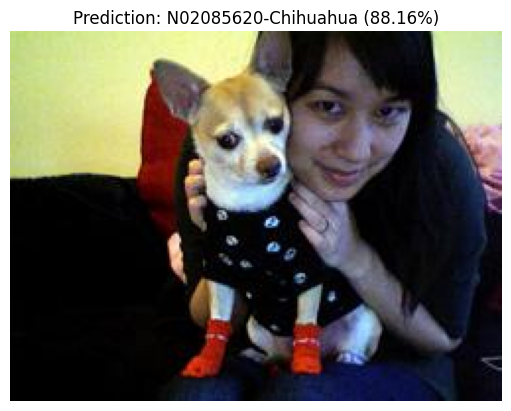

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

TEST_IMAGE_PATH = "/content/n02085620_7.jpg"  # Upload a dog picture to Colab and put its filename here

def run_visual_inference(img_path, model_path, class_mapping_path):
    with open(class_mapping_path, "r") as f:
        classes = json.load(f)

    eval_model = models.efficientnet_b0()
    eval_model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(eval_model.classifier[1].in_features, len(classes))
    )
    eval_model.load_state_dict(torch.load(model_path, map_location=device))
    eval_model = eval_model.to(device).eval()

    inference_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert("RGB")
    tensor = inference_transforms(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = eval_model(tensor)
        probs = torch.nn.functional.softmax(out[0], dim=0)

    conf, class_idx = torch.max(probs, dim=0)
    final_breed = classes[class_idx.item()].replace("_", " ").title()

    plt.imshow(raw_image)
    plt.title(f"Prediction: {final_breed} ({conf.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

# Run it
try:
    run_visual_inference(TEST_IMAGE_PATH, "best_dog_breed_model.pth", "breed_classes.json")
except FileNotFoundError:
    print(f"Upload a test image to Colab and rename TEST_IMAGE_PATH to test it live!")

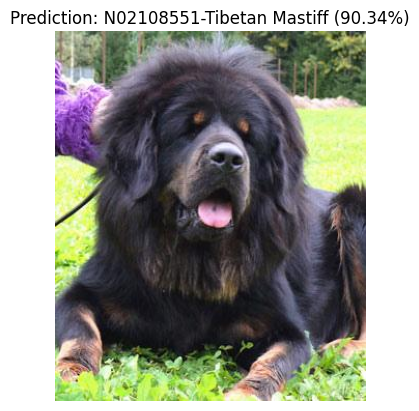

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

TEST_IMAGE_PATH = "/content/n02108551_441.jpg"  # Upload a dog picture to Colab and put its filename here

def run_visual_inference(img_path, model_path, class_mapping_path):
    with open(class_mapping_path, "r") as f:
        classes = json.load(f)

    eval_model = models.efficientnet_b0()
    eval_model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(eval_model.classifier[1].in_features, len(classes))
    )
    eval_model.load_state_dict(torch.load(model_path, map_location=device))
    eval_model = eval_model.to(device).eval()

    inference_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert("RGB")
    tensor = inference_transforms(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = eval_model(tensor)
        probs = torch.nn.functional.softmax(out[0], dim=0)

    conf, class_idx = torch.max(probs, dim=0)
    final_breed = classes[class_idx.item()].replace("_", " ").title()

    plt.imshow(raw_image)
    plt.title(f"Prediction: {final_breed} ({conf.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

# Run it
try:
    run_visual_inference(TEST_IMAGE_PATH, "best_dog_breed_model.pth", "breed_classes.json")
except FileNotFoundError:
    print(f"Upload a test image to Colab and rename TEST_IMAGE_PATH to test it live!")

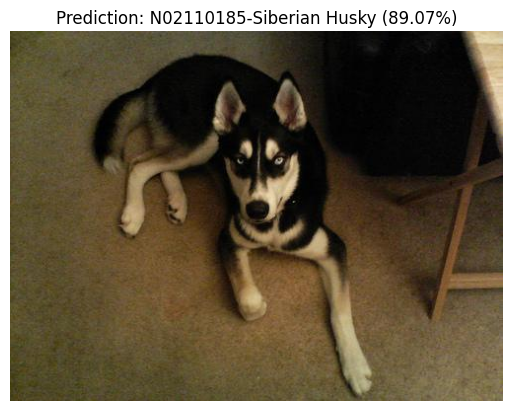

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

TEST_IMAGE_PATH = "/content/n02110185_725.jpg"  # Upload a dog picture to Colab and put its filename here

def run_visual_inference(img_path, model_path, class_mapping_path):
    with open(class_mapping_path, "r") as f:
        classes = json.load(f)

    eval_model = models.efficientnet_b0()
    eval_model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(eval_model.classifier[1].in_features, len(classes))
    )
    eval_model.load_state_dict(torch.load(model_path, map_location=device))
    eval_model = eval_model.to(device).eval()

    inference_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert("RGB")
    tensor = inference_transforms(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = eval_model(tensor)
        probs = torch.nn.functional.softmax(out[0], dim=0)

    conf, class_idx = torch.max(probs, dim=0)
    final_breed = classes[class_idx.item()].replace("_", " ").title()

    plt.imshow(raw_image)
    plt.title(f"Prediction: {final_breed} ({conf.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

# Run it
try:
    run_visual_inference(TEST_IMAGE_PATH, "best_dog_breed_model.pth", "breed_classes.json")
except FileNotFoundError:
    print(f"Upload a test image to Colab and rename TEST_IMAGE_PATH to test it live!")

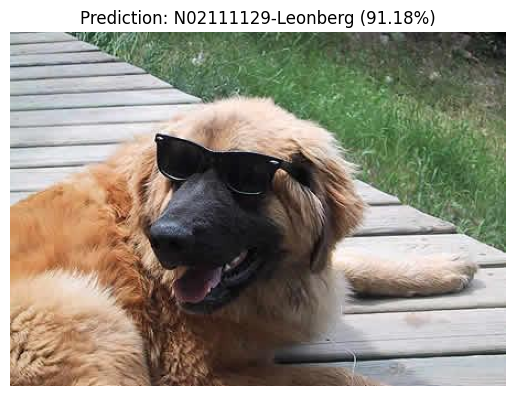

In [27]:
import matplotlib.pyplot as plt
from PIL import Image

TEST_IMAGE_PATH = "/content/n02111129_2072.jpg"  # Upload a dog picture to Colab and put its filename here

def run_visual_inference(img_path, model_path, class_mapping_path):
    with open(class_mapping_path, "r") as f:
        classes = json.load(f)

    eval_model = models.efficientnet_b0()
    eval_model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(eval_model.classifier[1].in_features, len(classes))
    )
    eval_model.load_state_dict(torch.load(model_path, map_location=device))
    eval_model = eval_model.to(device).eval()

    inference_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert("RGB")
    tensor = inference_transforms(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = eval_model(tensor)
        probs = torch.nn.functional.softmax(out[0], dim=0)

    conf, class_idx = torch.max(probs, dim=0)
    final_breed = classes[class_idx.item()].replace("_", " ").title()

    plt.imshow(raw_image)
    plt.title(f"Prediction: {final_breed} ({conf.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

# Run it
try:
    run_visual_inference(TEST_IMAGE_PATH, "best_dog_breed_model.pth", "breed_classes.json")
except FileNotFoundError:
    print(f"Upload a test image to Colab and rename TEST_IMAGE_PATH to test it live!")